#####  notes 

1. Data is saved.  Don't forget to save this data.  We've made a number of changes:
    1. renamed 'third-party' to 'third_party'
    1. added ' column (days since first installation in dataset)

1. It might be easier to interpret the models if I used size in watts rather than kwatts.

1.  done - need to get rid of all the entries with size_kw less that .1 (100 watts).  There's a few and they are mostly bogus; also extreme (i.e. wrong) cost_per_watt.  Did not get rid of data because of size of installation (there are some very big ones).  Only dropped where price and size did not produce a cost_per_watt in reasonable range.

1. done - got rid of extremely high cost/watt (and associated bogus size/price pairs).  

1. done - drop rows where cost/watt < \$1.  I believe most of these have one or more issues.  In any case, they are in no way typical of the kinds of data we want to model.

#### Data Story - is cost a function of time and size?

The master question: on what variables does cost_per_watt depend?

Here's a slightly different question: 

Within the same time frame and geog, do a commercial and residential customer pay the same for the same size install.


In [1]:
# %load ../pycode/setup.py
# set up
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

def ecdf(data):
    '''Compute ECDF for a one-dimensional array of measurements.'''
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n + 1) / n
    return x, y

def min015099max(series):
    ''' return list of [ min, 1%, median, 99%, max ] series values '''
    vals = list(np.percentile(series, [1.0, 50.0, 99.0]))
    vals.insert(-1, series.max())
    vals.insert(0, series.min())
    return vals

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)             

def mid98(series):
    '''  return middle 98% of series '''
    bounds = series.quantile([0.01, 0.99])
    return(series[(series > bounds.values[0]) & (series < bounds.values[1])])

# ss = np.arange(1, 101)
# min_1_50_99_max(ss)


In [2]:
pd.get_option("display.max_columns")

20

In [3]:
# some helpful printing options
np.set_printoptions(precision=4, suppress=False)
pd.set_option("display.max_columns", 25)

In [4]:
# revisit previous work with TTS data
# dfLive = pd.read_csv('../local/data/20180105', index_col='date_installed', parse_dates=True)
dftts = pd.read_csv('../local/data/LBNL_openpv_tts_data/ttsclean20180123.csv', 
                     index_col='row_id', 
                     parse_dates=['install_date'],
                     dtype={'zipcode' : object})

In [5]:
dftts.describe(include=[np.number, np.datetime64])

,file_row,install_date,size_kw,price,cost_per_watt
count,7.756940e+05,775694,775694.000000,7.756940e+05,775694.000000
unique,NaN,5426,NaN,NaN,NaN
top,NaN,2016-01-19 00:00:00,NaN,NaN,NaN
freq,NaN,1454,NaN,NaN,NaN
first,NaN,1998-01-09 00:00:00,NaN,NaN,NaN
last,NaN,2016-12-31 00:00:00,NaN,NaN,NaN
mean,1.379780e+07,NaN,10.886144,5.048951e+04,5.151572
std,4.699456e+06,NaN,67.554064,2.615469e+05,1.870340
min,1.000000e+07,NaN,0.108000,2.270000e+02,1.000000
25%,1.029787e+07,NaN,4.080000,1.975000e+04,4.016459


In [6]:
dftts.install_date.isnull().sum()

0

In [7]:
dftts.describe(include=[object])

,data_provider,sysid_dp,sysid_tts,cust_type,zipcode,city,county,state
count,775694,761815,775694,775694,775694,771762,592317,775694
unique,52,755096,775694,7,9712,9485,471,19
top,California Public Utilities Commission (Curren...,21,AZ-APS-2363,RES,95762.0,SAN DIEGO,SAN DIEGO,CA
freq,220324,10,1,745688,2639,22416,68921,456978


In [8]:
dftts.describe(include=[bool])

,appraised_value,new_const,tracking,ground_mounted,battery,third-party,uinverter,dc_optimizer
count,775694,775694,775694,775694,775694,775694,775694,775694
unique,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False
freq,547038,745951,772532,763352,775535,431039,616685,654080


In [10]:
# look at res size > 100kw
res_install = dftts['cust_type'] == 'RES'

In [11]:
res_huge = dftts.loc[res_install & (dftts.size_kw > 1000)]
res_huge.describe()
res_huge

,file_row,data_provider,sysid_dp,sysid_tts,install_date,size_kw,price,appraised_value,cust_type,new_const,tracking,ground_mounted,battery,zipcode,city,county,state,third-party,uinverter,dc_optimizer,cost_per_watt
row_id,,,,,,,,,,,,,,,,,,,,,
444065,10465392,California Public Utilities Commission (Curren...,SCE-INT-500520614 & SCE-CSI-58377,CA-NEM-370818,2014-06-10,1129.905,3110743.0,False,RES,False,False,False,False,92241.0,DESERT HOT SPRINGS,Riverside,CA,False,False,False,2.753101
539919,20150172,Massachusetts Department of Energy Resources,NFG-SR25630-36344,MA_DOER_CEC_44882,2014-12-18,1989.520,3720864.0,False,RES,False,False,False,False,2720.0,Fall River,NaN,MA,False,False,False,1.870232
546615,20146944,Massachusetts Department of Energy Resources,NFG-SR25630-28508,MA_DOER_CEC_41564,2014-12-30,1178.100,3100000.0,False,RES,False,False,False,False,1740.0,Bolton,NaN,MA,False,False,False,2.631356


In [12]:
# residential installs
dfRes = dftts[dftts.cust_type == 'RES']

In [13]:
# median res install is 5.75kw
dfRes.size_kw.describe()

count    745688.000000
mean          6.457227
std           7.099405
min           0.108000
25%           4.025560
50%           5.750000
75%           7.955000
max        1989.520000
Name: size_kw, dtype: float64

### Important!
__ The distribution below says that fully 95% of all residential installations are between 1.86kw and 14.26kw.__

 2.5%: 1.8400000000000003
  25%: 4.0255600000000005
  50%: 5.75
  75%: 7.955
97.5%: 14.260000000000002


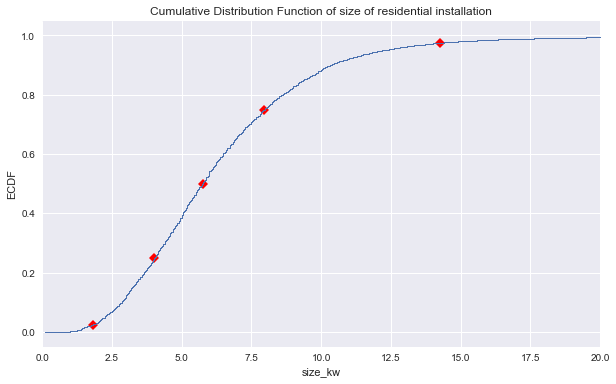

In [14]:
resSizes = dftts[dftts.cust_type == 'RES'].size_kw
xx, yy = ecdf(resSizes)
### shows a nice graph of size CDF with percentiles highlighted
percentiles = np.array([2.5, 25, 50, 75, 97.5])
ptiles = np.percentile(xx, percentiles)
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')
plt.xlim((0, 20))
plt.plot(xx, yy, marker='.', linestyle='none', markersize=2.0)
plt.xlabel('size_kw')
plt.ylabel('ECDF')
plt.title('Cumulative Distribution Function of size of residential installation');

print(' 2.5%: {}\n  25%: {}\n  50%: {}\n  75%: {}\n97.5%: {}'.format(*ptiles))

### Important!
__The distribution below says that fully 95% of all residential installations are between \$2.07 and \$9.41.__

 2.5%: 2.0726913623863727
  25%: 4.04
  50%: 4.941176470588236
  75%: 5.787037037037037
97.5%: 9.408070714285712


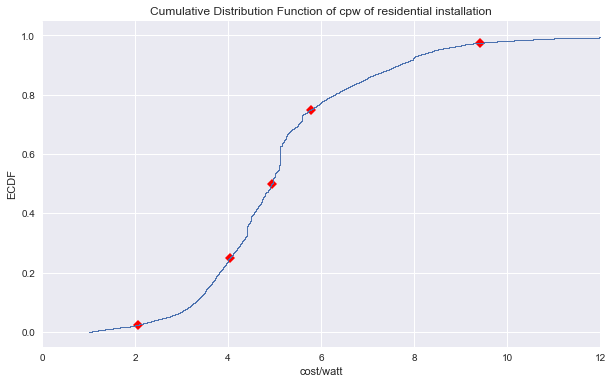

In [15]:
res_cpw = dftts[dftts.cust_type == 'RES'].cost_per_watt
xx, yy = ecdf(res_cpw)
### shows a nice graph of cpw CDF with percentiles highlighted
percentiles = np.array([2.5, 25, 50, 75, 97.5])
ptiles = np.percentile(xx, percentiles)
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')
plt.xlim((0, 12))
plt.plot(xx, yy, marker='.', linestyle='none', markersize=2.0)
plt.xlabel('cost/watt')
plt.ylabel('ECDF')
plt.title('Cumulative Distribution Function of cpw of residential installation');
print(' 2.5%: {}\n  25%: {}\n  50%: {}\n  75%: {}\n97.5%: {}'.format(*ptiles))

In [16]:
dfCom = dftts[dftts.cust_type == 'COM']

In [17]:
# median commercial install is 25.2kw, almost 5 times as big
dfCom.size_kw.describe()

count    15199.000000
mean       131.308669
std        373.813536
min          0.330000
25%         10.000000
50%         25.200000
75%         80.640000
max       5998.740000
Name: size_kw, dtype: float64

 2.5%: 2.12
  25%: 10.0
  50%: 25.2
  75%: 80.64
97.5%: 1084.302999999998


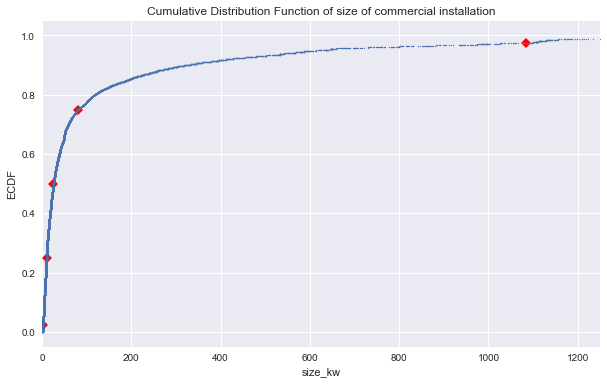

In [18]:
comSizes = dftts[dftts.cust_type == 'COM'].size_kw
xx, yy = ecdf(comSizes)
### shows a nice graph of size CDF with percentiles highlighted
percentiles = np.array([2.5, 25, 50, 75, 97.5])
ptiles = np.percentile(xx, percentiles)
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')
plt.xlim((0, 1250))
plt.plot(xx, yy, marker='.', linestyle='none', markersize=2.5)
plt.xlabel('size_kw')
plt.ylabel('ECDF')
plt.title('Cumulative Distribution Function of size of commercial installation');
print(' 2.5%: {}\n  25%: {}\n  50%: {}\n  75%: {}\n97.5%: {}'.format(*ptiles))

 2.5%: 1.8087697274031564
  25%: 3.308126627055491
  50%: 4.731034482758621
  75%: 6.931157687991021
97.5%: 10.464054158883844


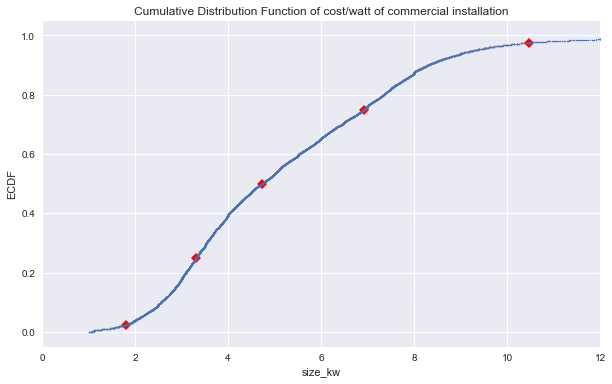

In [19]:
com_cpw = dftts[dftts.cust_type == 'COM'].cost_per_watt
xx, yy = ecdf(com_cpw)
### shows a nice graph of size CDF with percentiles highlighted
percentiles = np.array([2.5, 25, 50, 75, 97.5])
ptiles = np.percentile(xx, percentiles)
plt.plot(ptiles, percentiles/100, marker='D', color='red', linestyle='none')
plt.xlim(0, 12)
plt.plot(xx, yy, marker='.', linestyle='none', markersize=2.5)
plt.xlabel('size_kw')
plt.ylabel('ECDF')
plt.title('Cumulative Distribution Function of cost/watt of commercial installation');
print(' 2.5%: {}\n  25%: {}\n  50%: {}\n  75%: {}\n97.5%: {}'.format(*ptiles))

#### look at correlations between install_date (in days since day 0), size_kw and cost_per_watt

### set up for pairplot

In [20]:
dftts.iloc[0]

file_row                                                    10108220
data_provider      California Public Utilities Commission (Curren...
sysid_dp                                PGE-INT-11328 & CA_ERP_24698
sysid_tts                                               CA-NEM-12257
install_date                                     1998-01-09 00:00:00
size_kw                                                       2.2824
price                                                          24500
appraised_value                                                False
cust_type                                                        RES
new_const                                                      False
tracking                                                       False
ground_mounted                                                 False
battery                                                        False
zipcode                                                      94107.0
city                              

__Add a column that is the number of days since the first install in the data__

In [21]:
day0 = pd.to_datetime('1998-01-09')

In [22]:
num_days = (dftts.install_date - day0).apply(lambda x: x.days)

In [23]:
num_days.isnull().sum()

0

In [24]:
dftts = dftts.assign(num_days=num_days)

In [25]:
# first we need to fix dfRes because we've added a column
dfRes = dftts[dftts.cust_type == 'RES']

In [26]:
# I really didn't need to set this up as a separate df.  It's a hold-over from working with the previous dataset.
mdf = pd.DataFrame({'install_date'   : dftts.install_date.values,
                    'num_days'       : num_days,
                    'cost_per_watt'  : dftts.cost_per_watt.values,
                    'size_kw'        : dftts.size_kw.values})

In [27]:
mdf.head()

,cost_per_watt,install_date,num_days,size_kw
row_id,,,,
1,10.734315,1998-01-09,0,2.2824
2,11.108701,1998-01-30,21,1.8504
4,8.667013,1998-02-04,26,2.3076
6,13.270286,1998-04-03,84,2.3316
7,14.654839,1998-04-30,111,0.9300


__ I  don't know what to make of this.  I think cpw is negatively correlated with num_days and also negatively correlated with size_kw.  This doesn't say anything that I can interpret.__

__ One thing occurs to me.  I know from distribution above (and the one below) that 97.5% of the cost/watt values are less than \$9.41.  That means all of the stuff over that value in the graph below is a very small part of the data.  It's obscuring what's really happening in these graphics.




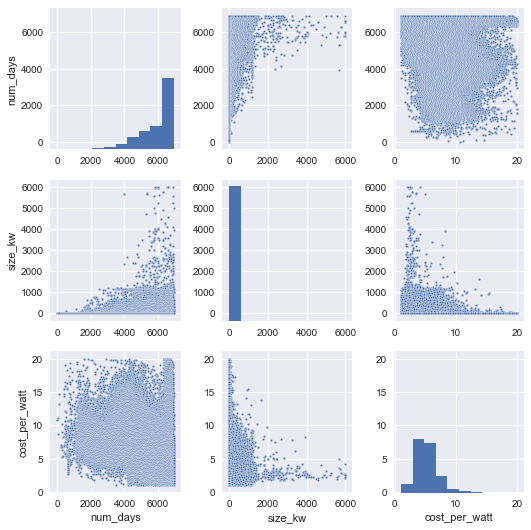

In [28]:
sns.pairplot(mdf[['num_days', 'size_kw', 'cost_per_watt']], plot_kws={"s": 6});

(0, 5)

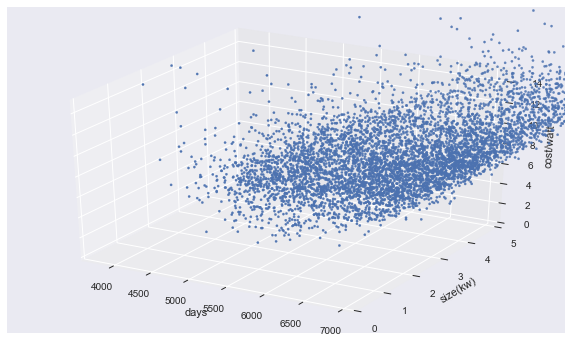

In [29]:
# just looking at New Mexico here to make it less confusing?  it didn't work.
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
nm = dftts[dftts.state == 'NM']
# nm = nm.drop(nm.cost_per_watt  < 0.20)
ax.scatter(nm.num_days, nm.size_kw, nm.cost_per_watt, marker='.')

ax.set_xlabel('days')
ax.set_ylabel('size(kw)')
ax.set_zlabel('cost/watt')

ax.set_zlim(0, 15)
ax.set_ylim(0, 5)

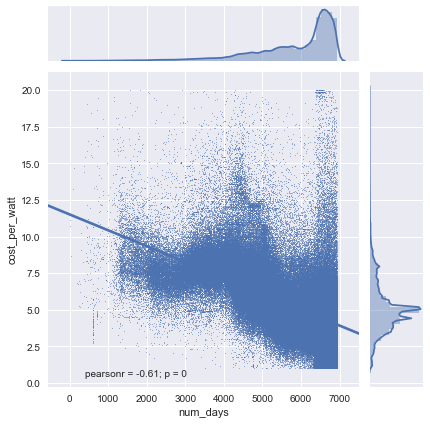

In [30]:
# full dataset cost_per_watt
sns.jointplot(x=dftts.num_days, y=dftts.cost_per_watt, kind='reg', scatter_kws={'s':0.5})

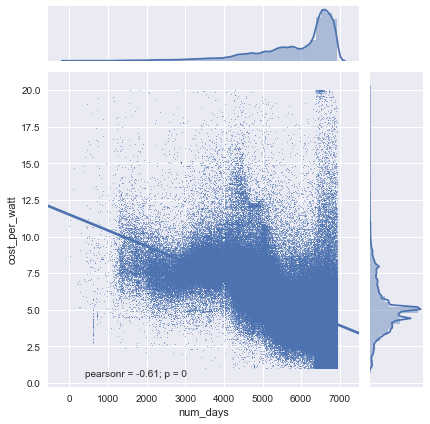

In [31]:
# residential cost_per_watt
sns.jointplot(x=dfRes.num_days, y=dfRes.cost_per_watt, kind='reg', scatter_kws={'s':0.5})

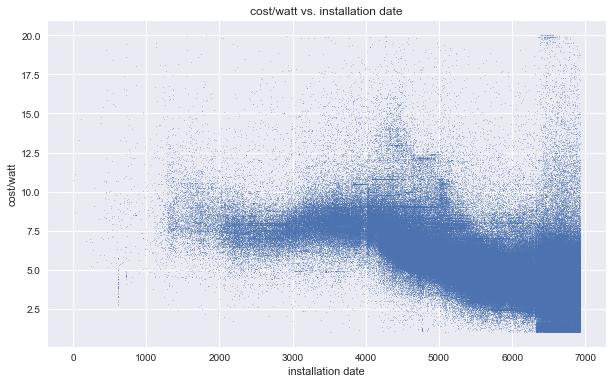

In [32]:
# what good is this graph?  redundant
plt.plot(dftts.num_days, dftts.cost_per_watt, marker='.', linestyle='none', markersize=1.0)
            
plt.xlabel('installation date')
plt.ylabel('cost/watt')
plt.title('cost/watt vs. installation date');


In [33]:
# most expensive installation; they didn't get much for their money.  
dftts.loc[dftts.cost_per_watt.argmax()]

file_row                              20362171
data_provider      Oregon Department of Energy
sysid_dp                                743721
sysid_tts                           OR_DOE_215
install_date               2002-04-19 00:00:00
size_kw                                    0.6
price                                    12000
appraised_value                          False
cust_type                                  RES
new_const                                False
tracking                                 False
ground_mounted                           False
battery                                  False
zipcode                                97734.0
city                                    CULVER
county                                    JEFF
state                                       OR
third-party                              False
uinverter                                False
dc_optimizer                             False
cost_per_watt                               20
num_days     

### Correlations between numerical variables

In [34]:
# let's see the correlation matrix for numerical values
corrMatrix  = dftts[['num_days', 'size_kw', 'price', 'cost_per_watt']].corr()

#### The correlation matrix  says:
1. Strong positve correlation between size and price.  this is actually a control since cost_per_watt was calculated using size and price.  I wonder why it's not higher.
2. Moderate negative correlation between cost_per_watt and time since day 1.
3. Cost_per_watt is not correlated with size.  I find this surprising.

In [35]:
print(corrMatrix)

               num_days   size_kw     price  cost_per_watt
num_days       1.000000 -0.006031 -0.052589      -0.611365
size_kw       -0.006031  1.000000  0.890117      -0.044252
price         -0.052589  0.890117  1.000000       0.028031
cost_per_watt -0.611365 -0.044252  0.028031       1.000000


In [36]:
# Now look at residential only
ResCorrMatrix  = dfRes[['num_days', 'size_kw', 'price', 'cost_per_watt']].corr()
print(ResCorrMatrix)

               num_days   size_kw     price  cost_per_watt
num_days       1.000000  0.057994 -0.104786      -0.611366
size_kw        0.057994  1.000000  0.835020      -0.106601
price         -0.104786  0.835020  1.000000       0.153362
cost_per_watt -0.611366 -0.106601  0.153362       1.000000


In [37]:
# Now look at commercial only
# first we need to fix dfCom because we've added a column
dfCom = dftts[dftts.cust_type == 'COM']
ComCorrMatrix  = dfCom[['num_days', 'size_kw', 'price', 'cost_per_watt']].corr()
print(ComCorrMatrix)

               num_days   size_kw     price  cost_per_watt
num_days       1.000000  0.096294 -0.017947      -0.654349
size_kw        0.096294  1.000000  0.911006      -0.203049
price         -0.017947  0.911006  1.000000      -0.062102
cost_per_watt -0.654349 -0.203049 -0.062102       1.000000


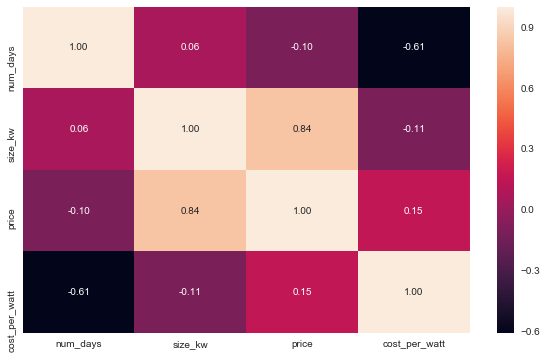

In [38]:
sns.heatmap(ResCorrMatrix, annot=True, fmt=".2f")

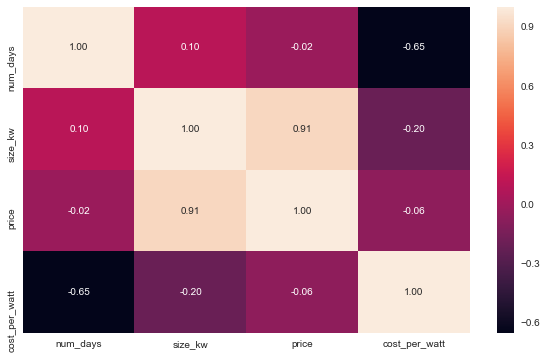

In [39]:
sns.heatmap(ComCorrMatrix, annot=True, fmt=".2f")

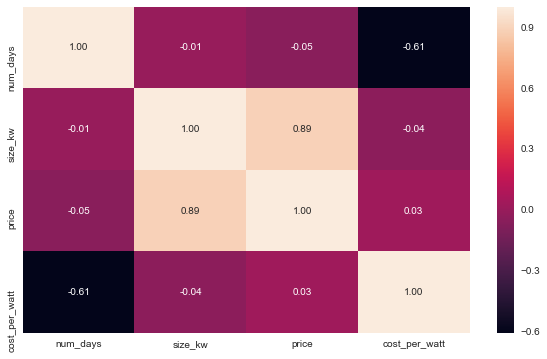

In [40]:
# this is all the data; it's probably dominated by residential.
sns.heatmap(corrMatrix,  annot=True, fmt=".2f")

### Let's see a regression of cost/watt vs time with distributions

I think the outliers on the high side are messing with me here.  They are way out and matter too much because of the square in the error fn.

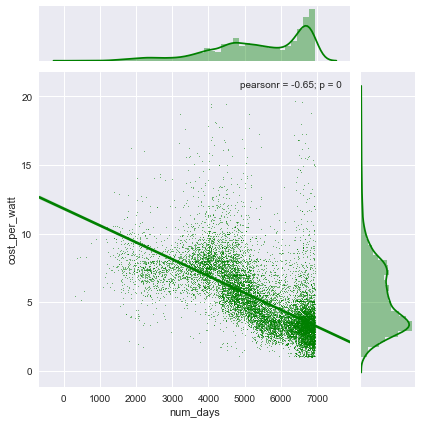

In [41]:
sns.jointplot(data=dfCom, x='num_days', y='cost_per_watt', kind='reg', color='g',  scatter_kws={'s':0.5})

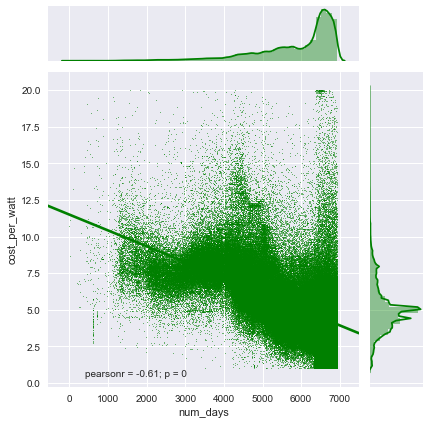

In [42]:
# there's really too much here to see what's going on...
# but it definitely pulls the regression out.
sns.jointplot(data=dfRes, x='num_days', y='cost_per_watt', kind='reg', color='g', scatter_kws={'s':0.5})

#### Let's see what we can do with the state.  Does it matter?

In [43]:
# how many in each state
dftts.state.value_counts()

CA    456978
AZ     86630
MA     66748
NY     64343
CT     19458
NV     18916
TX     14765
NJ      7980
MD      7412
PA      7274
NM      6299
VT      3932
NH      3516
OR      2769
DE      2754
WI      2581
FL      2057
MN      1180
AR       102
Name: state, dtype: int64

In [44]:
# group by state and year
byStateYear = dftts.groupby([dftts.state, dftts.install_date.apply(lambda x: x.year)])

In [45]:
# same but just residential
resByStateYear = dfRes.groupby([dftts.state, dftts.install_date.apply(lambda x: x.year)])

In [46]:
# what does this look like?
byStateYear.cost_per_watt.mean().head()

state  install_date
AR     2010            6.228310
       2011            6.369712
AZ     1999            4.211903
       2000            4.577296
       2001            3.774847
Name: cost_per_watt, dtype: float64

In [47]:
# mean cost/watt by state and year
byStateYearCPW = byStateYear.cost_per_watt.mean()

In [48]:
# same but only residential
resByStateYearCPW = resByStateYear.cost_per_watt.mean()

In [49]:
# reshape for plot
dfYearStateCPW = byStateYearCPW.unstack('state')

In [50]:
# reshape for plot
dfResYearStateCPW = resByStateYearCPW.unstack('state')

In [51]:
# did it happen the way I thought?
dfYearStateCPW.head()

state,AR,AZ,CA,CT,DE,FL,MA,MD,MN,NH,NJ,NM,NV,NY,OR,PA,TX,VT,WI
install_date,,,,,,,,,,,,,,,,,,,
1998,NaN,NaN,8.478740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999,NaN,4.211903,8.875026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.722500,NaN,NaN,NaN,NaN
2000,NaN,4.577296,8.822687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.805500,10.862925,NaN,NaN,NaN,NaN
2001,NaN,3.774847,8.678836,NaN,NaN,NaN,4.814815,NaN,4.765217,3.779219,8.621688,NaN,NaN,8.883087,11.624167,NaN,6.291185,NaN,NaN
2002,NaN,9.200209,8.532035,NaN,4.777508,NaN,14.402407,NaN,5.086818,4.453989,8.679179,NaN,NaN,8.523609,10.887886,9.187462,NaN,NaN,9.664308


In [52]:
# different strokes for different states
styler = {'CA' : 'b-^', 'AZ' : 'g-^', 'MA' : 'r-^', 'NY' : 'c-^',
          'CT' : 'm-^', 'NV' :  'k-^', 'TX' :  'b:.', 'NJ' : 'g:.',
          'MD' : 'r:.', 'PA' : 'c:.', 'NM' : 'm:.', 'VT' : 'k:.',
          'NH' : 'b', 'OR' : 'g', 'DE' : 'r', 'WI' : 'c', 'FL' : 'm',
          'MN' : 'k', 'AK' : 'b'
}

Text(0,0.5,'cost/watt')

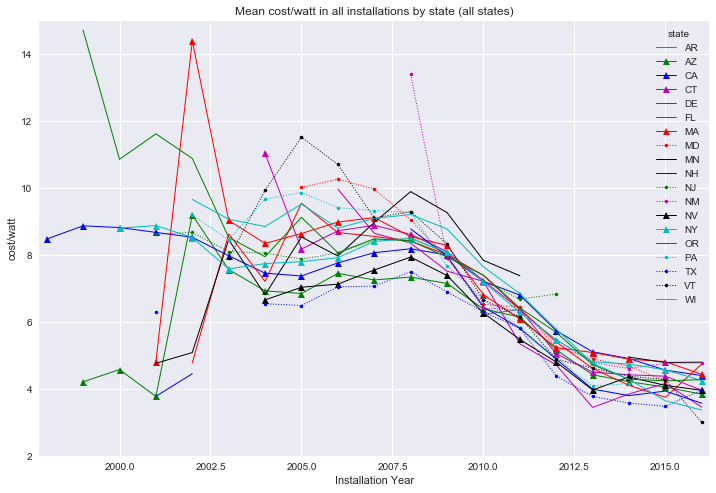

In [53]:
# all the states
fig, ax = plt.subplots(figsize=(12, 8))
dfYearStateCPW.plot(style=styler, ax=ax, linewidth=1.0, ylim=(2,15))
ax.set_xlim(1997.8, 2016.2)
ax.set_title('Mean cost/watt in all installations by state (all states)')
ax.set_xlabel('Installation Year')
ax.set_ylabel('cost/watt')

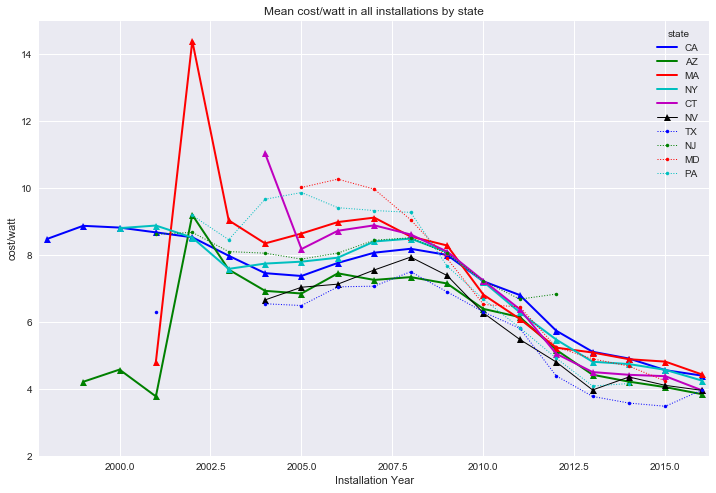

In [54]:
# just the top 10 states
fig, ax = plt.subplots(figsize=(12,8))
dfYearStateCPW[['CA', 'AZ', 'MA', 'NY', 'CT']].plot(style=styler, ax=ax, linewidth=2.0, ylim=(2,15))
dfYearStateCPW[['NV', 'TX', 'NJ', 'MD', 'PA' ]].plot(style=styler, ax=ax, linewidth=1.0, ylim=(2,15))
ax.set_xlim(1997.8, 2016.2)
ax.set_title('Mean cost/watt in all installations by state')
ax.set_xlabel('Installation Year')
ax.set_ylabel('cost/watt');

Text(0,0.5,'cost/watt')

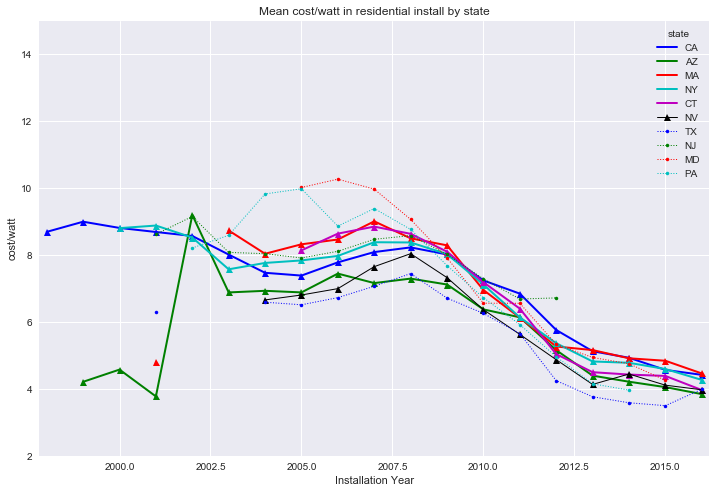

In [55]:
# top 10 states, only residential data 
fig, ax = plt.subplots(figsize=(12,8))
dfResYearStateCPW[['CA', 'AZ', 'MA', 'NY', 'CT',]].plot(style=styler, ax=ax, linewidth=2.0, ylim=(2,15))
dfResYearStateCPW[['NV', 'TX', 'NJ', 'MD', 'PA' ]].plot(style=styler, ax=ax, linewidth=1.0, ylim=(2,15))
ax.set_xlim(1997.8, 2016.2)
ax.set_title('Mean cost/watt in residential install by state')
ax.set_xlabel('Installation Year')
ax.set_ylabel('cost/watt')

#### What does a full correlation matrix tell us?

In [56]:
resCorr = dfRes.corr()

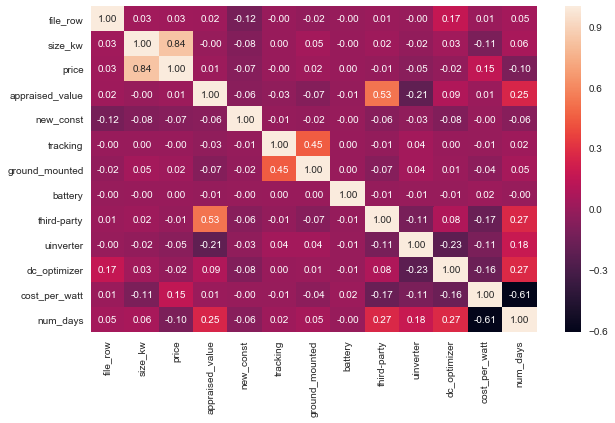

In [57]:
sns.heatmap(resCorr,  annot=True, fmt=".2f")

#### Let's take the plunge and see what a model says.

We're getting quite poor predictions of target and it may have to do with large number of outlying values.  One way to test that hypothesis is to remove the top 1% or 2.5% of prices and see what happens to $R^2$.  It's important to remember that $R^2$ tells you how much of the variance in the target is due to the model parameters.  

In [58]:
# rename annoying row
dfRes.rename(index=str, columns={"third-party": "third_party"}, inplace=True)

C:\Users\saus\Anaconda3\lib\site-packages\pandas\core\frame.py:2746: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  **kwargs)


In [59]:
dfRes.head()

,file_row,data_provider,sysid_dp,sysid_tts,install_date,size_kw,price,appraised_value,cust_type,new_const,tracking,ground_mounted,battery,zipcode,city,county,state,third_party,uinverter,dc_optimizer,cost_per_watt,num_days
row_id,,,,,,,,,,,,,,,,,,,,,,
1,10108220,California Public Utilities Commission (Curren...,PGE-INT-11328 & CA_ERP_24698,CA-NEM-12257,1998-01-09,2.2824,24500.00,False,RES,False,False,False,False,94107.0,San Francisco,San Francisco,CA,False,False,False,10.734315,0
2,10107162,California Public Utilities Commission (Curren...,PGE-INT-11220 & CA_ERP_24687,CA-NEM-11180,1998-01-30,1.8504,20555.54,False,RES,False,False,False,False,95949.0,Nevada City,Nevada,CA,False,False,False,11.108701,21
4,10107618,California Public Utilities Commission (Curren...,PGE-INT-11268 & CA_ERP_24540,CA-NEM-11641,1998-02-04,2.3076,20000.00,False,RES,False,False,False,False,94518.0,Concord,Contra Costa,CA,False,False,False,8.667013,26
6,10107745,California Public Utilities Commission (Curren...,PGE-INT-11280 & CA_ERP_24429,CA-NEM-11770,1998-04-03,2.3316,30941.00,False,RES,False,False,False,False,94038.0,Moss Beach,San Mateo,CA,False,False,False,13.270286,84
7,10107787,California Public Utilities Commission (Curren...,PGE-INT-11284 & CA_ERP_24701,CA-NEM-11812,1998-04-30,0.9300,13629.00,False,RES,False,False,False,False,94563.0,Orinda,Contra Costa,CA,False,False,False,14.654839,111


In [60]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

C:\Users\saus\Anaconda3\lib\site-packages\statsmodels\compat\pandas.py:56: FutureWarning: The pandas.core.datetools module is deprecated and will be removed in a future version. Please use the pandas.tseries module instead.
  from pandas.core import datetools


In [75]:
m0 = ols('cost_per_watt ~ num_days', dfRes).fit()
print(m0.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_per_watt   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                 4.451e+05
Date:                Fri, 26 Jan 2018   Prob (F-statistic):               0.00
Time:                        23:16:29   Log-Likelihood:            -1.3408e+06
No. Observations:              745688   AIC:                         2.682e+06
Df Residuals:                  745686   BIC:                         2.682e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.4934      0.010   1189.029      0.0

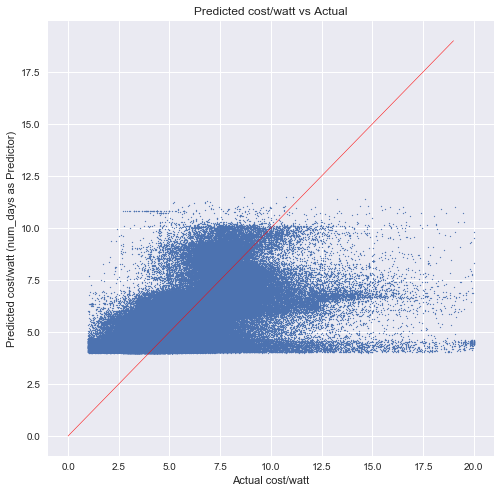

In [79]:
# hmmm
plt.rc('figure', figsize=(8,8))
plt.clf()
plt.scatter(x=dfRes.cost_per_watt, y=m0.fittedvalues, s=1)
x = np.arange(0, max(dfRes.cost_per_watt)); y = x.copy()
plt.plot(x, y, color='red', linewidth=0.5)
plt.title('Predicted cost/watt vs Actual')
plt.xlabel('Actual cost/watt' )
plt.ylabel('Predicted cost/watt (num_days as Predictor)')
plt.show()

In [77]:
m1 = ols('cost_per_watt ~ num_days + size_kw', dfRes).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_per_watt   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                 2.274e+05
Date:                Fri, 26 Jan 2018   Prob (F-statistic):               0.00
Time:                        23:18:25   Log-Likelihood:            -1.3378e+06
No. Observations:              745688   AIC:                         2.676e+06
Df Residuals:                  745685   BIC:                         2.676e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.5703      0.010   1195.628      0.0

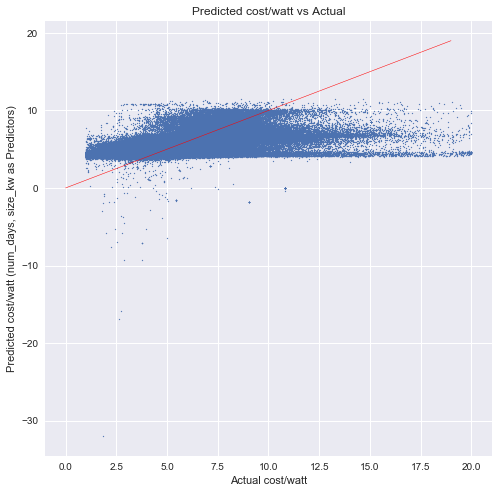

In [80]:
# hmmm, now I get negative predictions; I bet those are very large installations
plt.clf()
plt.scatter(x=dfRes.cost_per_watt, y=m1.fittedvalues, s=1)
x = np.arange(0, max(dfRes.cost_per_watt)); y = x.copy()
plt.plot(x, y, color='red', linewidth=0.5)
plt.title('Predicted cost/watt vs Actual')
plt.xlabel('Actual cost/watt' )
plt.ylabel('Predicted cost/watt (num_days, size_kw as Predictors)')
plt.show()

In [86]:
m2 = ols('cost_per_watt ~ num_days + size_kw +C(state)', dfRes).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_per_watt   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                 2.458e+04
Date:                Fri, 26 Jan 2018   Prob (F-statistic):               0.00
Time:                        23:30:50   Log-Likelihood:            -1.3265e+06
No. Observations:              745688   AIC:                         2.653e+06
Df Residuals:                  745667   BIC:                         2.653e+06
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         11.4314      0.152     75.

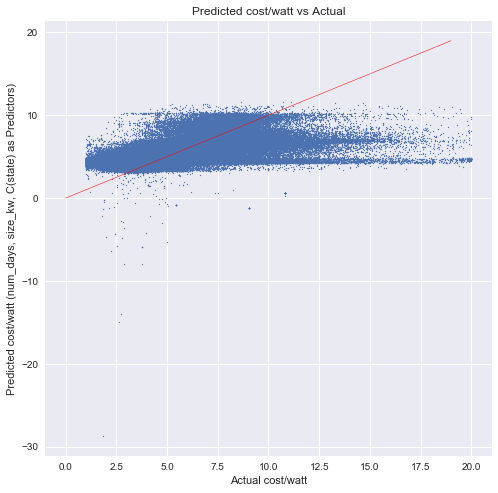

In [87]:
# hmmm
plt.clf()
plt.scatter(x=dfRes.cost_per_watt, y=m2.fittedvalues, s=1)
x = np.arange(0, max(dfRes.cost_per_watt)); y = x.copy()
plt.plot(x, y, color='red', linewidth=0.5)
plt.title('Predicted cost/watt vs Actual')
plt.xlabel('Actual cost/watt' )
plt.ylabel('Predicted cost/watt (num_days, size_kw, C(state) as Predictors)')
plt.show()

In [89]:
# take out state, add in third_party, uinverter, appraised value
m3 = ols('cost_per_watt ~ num_days + size_kw + third_party + uinverter + appraised_value', dfRes).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_per_watt   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                 1.080e+05
Date:                Fri, 26 Jan 2018   Prob (F-statistic):               0.00
Time:                        23:34:42   Log-Likelihood:            -1.3122e+06
No. Observations:              745688   AIC:                         2.624e+06
Df Residuals:                  745682   BIC:                         2.625e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [91]:
# add state back in
m4 = ols('cost_per_watt ~ num_days + size_kw + third_party + uinverter + appraised_value + C(state)', dfRes).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_per_watt   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                 2.557e+04
Date:                Fri, 26 Jan 2018   Prob (F-statistic):               0.00
Time:                        23:40:27   Log-Likelihood:            -1.2985e+06
No. Observations:              745688   AIC:                         2.597e+06
Df Residuals:                  745664   BIC:                         2.597e+06
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

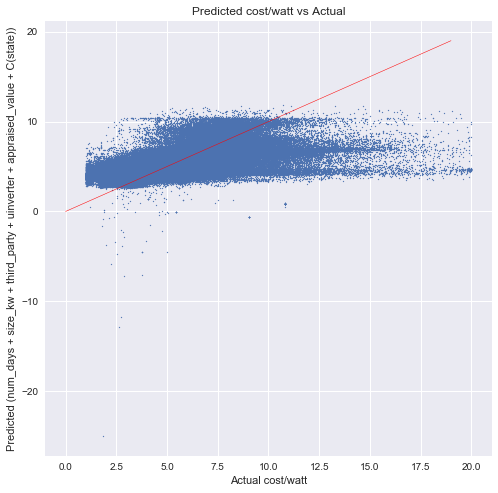

In [92]:
# 
# 
plt.clf()
plt.scatter(x=dfRes.cost_per_watt, y=m4.fittedvalues, s=1)
x = np.arange(0,20); y = x.copy()
plt.plot(x, y, color='red', linewidth=0.5)
plt.title('Predicted cost/watt vs Actual')
plt.xlabel('Actual cost/watt' )
plt.ylabel('Predicted (num_days + size_kw + third_party + uinverter + appraised_value + C(state))')
plt.show()

In [96]:
dftts.to_csv('../local/data/LBNL_openpv_tts_data/ttsclean20180127.csv')

In [1]:
print('still alive')

still alive
